In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('../data/train_data.csv')
df["price_billion"] = df["price_total"] / 1000000000
df = df[df['area'].between(15, 1000) & df['price_billion'].between(0.5, 60)]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 30682 entries, 0 to 32296
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price_total        30682 non-null  int64  
 1   area               30682 non-null  float64
 2   price_per_m2       30682 non-null  float64
 3   category           30682 non-null  object 
 4   latitude           30682 non-null  float64
 5   longitude          30682 non-null  float64
 6   district           30682 non-null  object 
 7   province           30682 non-null  object 
 8   legal_status       30682 non-null  object 
 9   frontage           30682 non-null  float64
 10  road_width         30682 non-null  float64
 11  num_bedrooms       30682 non-null  int64  
 12  num_toilets        30682 non-null  int64  
 13  num_floors         30682 non-null  int64  
 14  num_schools_1km    30682 non-null  int64  
 15  num_hospitals_2km  30682 non-null  int64  
 16  num_markets_1km    30682 no

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Lựa chọn các biến độc lập (X) và biến phụ thuộc (y)
# Loại bỏ cột 'price_total', 'price_billion' và 'price_per_m2' khỏi tập feature
X = df.drop(columns=['price_total', 'price_billion', 'price_per_m2'])
y = df['price_billion'] # Dự đoán giá theo đơn vị Tỷ VNĐ

# Chia dữ liệu thành tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tự động nhận diện cột dạng số và dạng phân loại (category)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Tạo Pipeline xử lý số: Điền giá trị thiếu (median) và Chuẩn hóa dữ liệu (StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Tạo Pipeline xử lý phân loại: Điền giá trị thiếu (mode) và One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Gộp các Pipeline lại
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Đã thiết lập xong quy trình tiền xử lý dữ liệu!")

Đã thiết lập xong quy trình tiền xử lý dữ liệu!


Training Ridge Regression to extract weights...

REGRESSION COEFFICIENTS TABLE (TOP 10 MOST INFLUENTIAL FACTORS):


,Feature,Coefficient
17,district_Huyện Ba Vì,-11.944989
22,district_Huyện Củ Chi,-11.337594
77,district_Quận Tây Hồ,10.479350
13,"category_Nhà biệt thự, liền kề",8.219361
23,district_Huyện Dầu Tiếng,-8.158186
26,district_Huyện Hòa Vang,-7.068587
55,district_Quận Ba Đình,6.344960
68,district_Quận Long Biên,6.079484
80,district_Thành phố Dĩ An,5.877042
45,district_Quận 1,5.553917


C:\Users\84333\AppData\Local\Temp\ipykernel_10720\1347386099.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


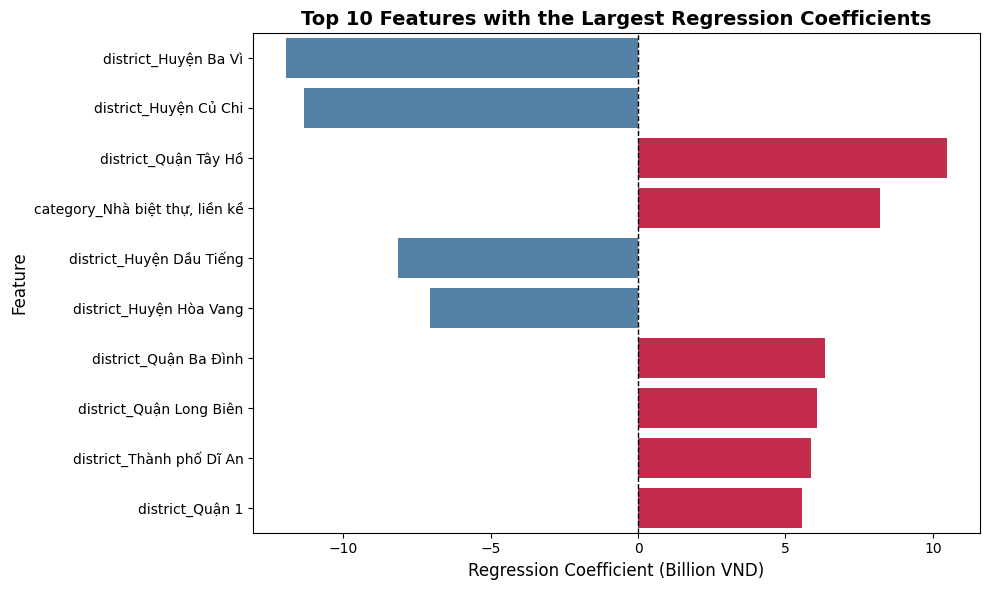

✔️ Successfully exported and saved the chart to 'ridge_coefficients.png'!


In [5]:
# %% TRÍCH XUẤT HỆ SỐ HỒI QUY BẰNG RIDGE REGRESSION ĐỂ TRÁNH ĐA CỘNG TUYẾN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge # <-- Đổi sang dùng Ridge
from sklearn.pipeline import Pipeline

print("Training Ridge Regression to extract weights...")

# 1. Dùng Ridge thay vì LinearRegression để khắc phục Đa cộng tuyến
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0)) # alpha càng lớn thì nó càng ép hệ số ảo xuống
])

# 2. Huấn luyện mô hình
lr_pipeline.fit(X_train, y_train)

# 3. Trích xuất tên các cột
feature_names = preprocessor.get_feature_names_out()

# 4. Trích xuất hệ số hồi quy (coef_)
lr_model = lr_pipeline.named_steps['model']
coefficients = lr_model.coef_

# 5. Đưa vào DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Dọn dẹp tên cột cho đẹp
coef_df['Feature'] = coef_df['Feature'].str.replace('num__', '', regex=False).str.replace('cat__', '', regex=False)

# 6. Lấy Top 10 đặc trưng có mức độ ảnh hưởng mạnh nhất
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_10_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print("\nREGRESSION COEFFICIENTS TABLE (TOP 10 MOST INFLUENTIAL FACTORS):")
display(top_10_features[['Feature', 'Coefficient']])

# 7. VẼ BIỂU ĐỒ VÀ LƯU ẢNH
plt.figure(figsize=(10, 6))

colors = top_10_features['Coefficient'].apply(lambda x: 'crimson' if x > 0 else 'steelblue')

sns.barplot(
    data=top_10_features, 
    x='Coefficient', 
    y='Feature', 
    palette=colors.tolist()
)

plt.title('Top 10 Features with the Largest Regression Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Regression Coefficient (Billion VND)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) 

plt.tight_layout()
plt.savefig('ridge_coefficients.png', dpi=300)
plt.show()

print("✔️ Successfully exported and saved the chart to 'ridge_coefficients.png'!")

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Import các hàm đánh giá
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Khởi tạo Dictionary chứa tất cả các mô hình
models = {
    "Linear Regression": LinearRegression(),        
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR (Support Vector)": SVR(),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

# Danh sách lưu kết quả
results =[]

print("Đang tiến hành huấn luyện các mô hình. Vui lòng đợi trong ít phút...\n")

for name, model in models.items():
    # Tạo Pipeline hoàn chỉnh: Tiền xử lý -> Mô hình
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Huấn luyện
    pipeline.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = pipeline.predict(X_test)
    
    # Đánh giá
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Lưu vào kết quả
    results.append({
        "Model": name,
        "R-squared (R2)": r2,
        "RMSE (Tỷ VNĐ)": rmse,
        "MAE (Tỷ VNĐ)": mae
    })
    
    print(f"✔️ Đã train xong: {name}")

print("\nHoàn tất huấn luyện!")


Đang tiến hành huấn luyện các mô hình. Vui lòng đợi trong ít phút...

✔️ Đã train xong: Linear Regression
✔️ Đã train xong: Ridge Regression
✔️ Đã train xong: Lasso Regression
✔️ Đã train xong: ElasticNet
✔️ Đã train xong: Decision Tree
✔️ Đã train xong: Random Forest


In [ ]:
# Chuyển kết quả thành DataFrame để dễ xem
results_df = pd.DataFrame(results)

# Đổi tên cột từ tiếng Việt sang tiếng Anh để khi in ra bảng được đồng bộ
results_df = results_df.rename(columns={
    "RMSE (Tỷ VNĐ)": "RMSE (Billion VND)",
    "MAE (Tỷ VNĐ)": "MAE (Billion VND)"
})

# Sắp xếp các mô hình theo độ tốt (R-squared giảm dần)
# R2 càng gần 1 càng tốt, RMSE và MAE càng nhỏ càng tốt
results_df = results_df.sort_values(by="R-squared (R2)", ascending=False).reset_index(drop=True)

# In bảng kết quả
print("MODEL PERFORMANCE COMPARISON TABLE (SORTED FROM BEST TO WORST):")
display(results_df.style.background_gradient(cmap='Blues', subset=['R-squared (R2)'])
                  .background_gradient(cmap='Reds_r', subset=['RMSE (Billion VND)', 'MAE (Billion VND)']))

MODEL PERFORMANCE COMPARISON TABLE (SORTED FROM BEST TO WORST):


,Model,R-squared (R2),RMSE (Billion VND),MAE (Billion VND)
0,Extra Trees,0.848608,4.016815,2.089744
1,CatBoost,0.845282,4.060707,2.322291
2,Random Forest,0.843933,4.078370,2.157832
3,XGBoost,0.843047,4.089936,2.326198
4,LightGBM,0.831225,4.241160,2.418388
5,Neural Network (MLP),0.768947,4.962345,2.774025
6,Gradient Boosting,0.762728,5.028680,3.036464
7,SVR (Support Vector),0.724651,5.417171,2.898606
8,KNN Regressor,0.695713,5.694725,3.076254
9,Decision Tree,0.649089,6.115467,3.045548


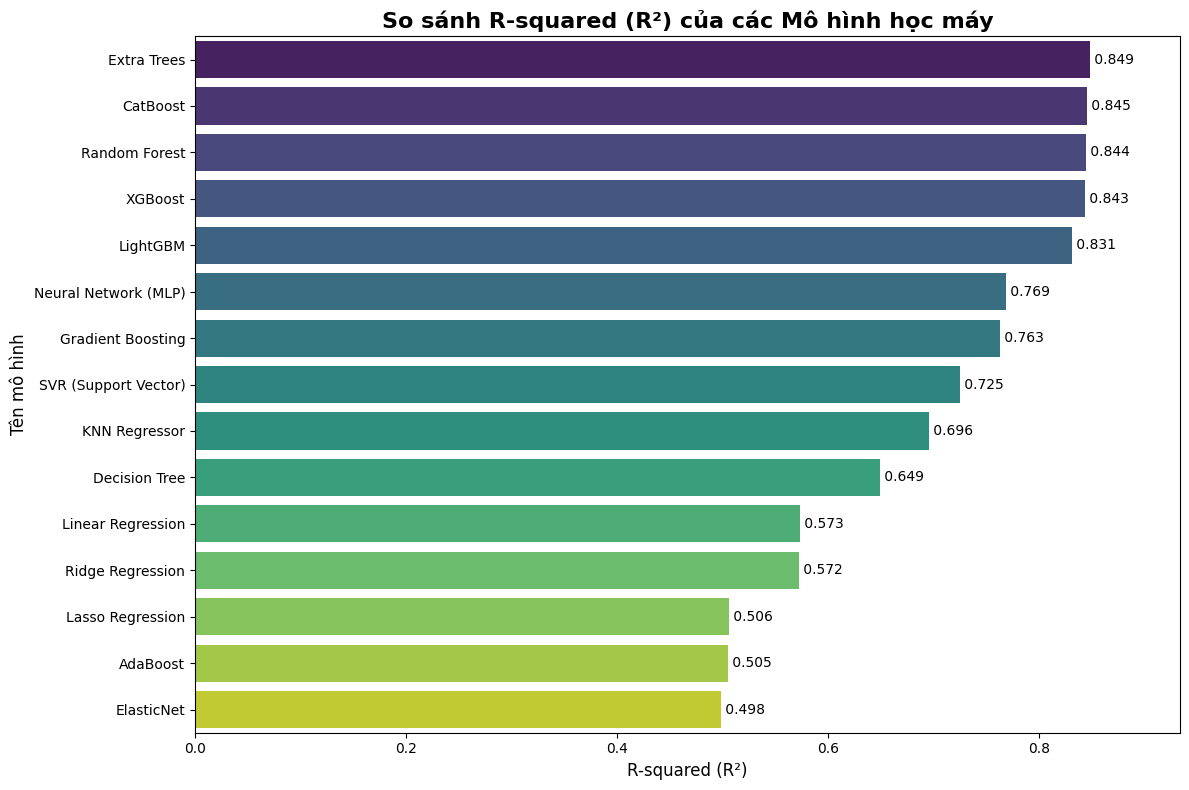

In [ ]:
# VẼ BIỂU ĐỒ SO SÁNH ĐỘ CHÍNH XÁC (R-SQUARED)
plt.figure(figsize=(12, 8))

sns.barplot(
    data=results_df, 
    x='R-squared (R2)', 
    y='Model', 
    hue='Model',
    palette='viridis',
    legend=False
)

plt.title('So sánh R-squared (R²) của các Mô hình học máy', fontsize=16, fontweight='bold')
plt.xlabel('R-squared (R²)', fontsize=12)
plt.ylabel('Tên mô hình', fontsize=12)

# Hiển thị giá trị R2 trên từng thanh bar
for index, value in enumerate(results_df['R-squared (R2)']):
    plt.text(value, index, f" {value:.3f}", va='center', fontsize=10)

plt.xlim(0, max(results_df['R-squared (R2)']) * 1.1)
plt.tight_layout()
plt.show()

In [ ]:
# VẼ BIỂU ĐỒ SO SÁNH SAI SỐ MAE (TỶ VNĐ)
plt.figure(figsize=(12, 8))

# Sắp xếp lại df theo MAE tăng dần (sai số nhỏ nhất lên đầu)
results_df_mae = results_df.sort_values(by="MAE (Tỷ VNĐ)", ascending=True)

sns.barplot(
    data=results_df_mae, 
    x='MAE (Tỷ VNĐ)', 
    y='Model', 
    hue='Model',
    palette='rocket_r',
    legend=False
)

plt.title('So sánh Sai số trung bình tuyệt đối - MAE (Tỷ VNĐ)', fontsize=16, fontweight='bold')
plt.xlabel('MAE (Càng nhỏ càng tốt)', fontsize=12)
plt.ylabel('Tên mô hình', fontsize=12)

for index, value in enumerate(results_df_mae['MAE (Tỷ VNĐ)']):
    plt.text(value, index, f" {value:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined